🔹 🔸 Cell 1: Import Libraries

In [11]:
import pandas as pd
import numpy as np

🔹 🔸 Cell 2: Load Data

In [3]:
listings = pd.read_csv('../data/raw/Listings.csv', encoding='latin1')
reviews = pd.read_csv('../data/raw/Reviews.csv', encoding='latin1')

print("Listings shape:", listings.shape)
print("Reviews shape:", reviews.shape)

C:\Users\Shree\AppData\Local\Temp\ipykernel_8276\3826496655.py:1: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('../data/raw/Listings.csv', encoding='latin1')


Listings shape: (279712, 33)
Reviews shape: (5373143, 4)


🔹 🔸 Cell 3: Preview Data

In [4]:
listings.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


reviews.head()

🔹 🔸 Cell 4: Column Info

In [5]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  str    
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  str    
 4   host_location                278872 non-null  str    
 5   host_response_time           150930 non-null  str    
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  str    
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  str    
 11  host_identity_verified       279547 non-null  str    
 12  neighbourhood                279712 non-null  str    
 13  district  

In [6]:
reviews.info()

<class 'pandas.DataFrame'>
RangeIndex: 5373143 entries, 0 to 5373142
Data columns (total 4 columns):
 #   Column       Dtype
---  ------       -----
 0   listing_id   int64
 1   review_id    int64
 2   date         str  
 3   reviewer_id  int64
dtypes: int64(3), str(1)
memory usage: 164.0 MB


🔹 🔸 Cell 5: Check Missing Values

In [7]:
listings.isnull().sum().sort_values(ascending=False)

district                       242700
host_response_time             128782
host_response_rate             128782
host_acceptance_rate           113087
review_scores_value             91785
review_scores_location          91775
review_scores_checkin           91771
review_scores_accuracy          91713
review_scores_communication     91687
review_scores_cleanliness       91665
review_scores_rating            91405
bedrooms                        29435
host_location                     840
name                              175
host_total_listings_count         165
host_is_superhost                 165
host_since                        165
host_identity_verified            165
host_has_profile_pic              165
listing_id                          0
longitude                           0
host_id                             0
latitude                            0
city                                0
neighbourhood                       0
maximum_nights                      0
minimum_nigh

In [8]:
reviews.isnull().sum().sort_values(ascending=False)

listing_id     0
review_id      0
date           0
reviewer_id    0
dtype: int64

🔹 🔸 Cell 6: Describe Data

In [9]:
listings.describe()

,listing_id,host_id,host_response_rate,host_acceptance_rate,host_total_listings_count,latitude,longitude,accommodates,bedrooms,price,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
count,2.797120e+05,2.797120e+05,150930.000000,166625.000000,279547.000000,279712.000000,279712.000000,279712.000000,250277.000000,279712.000000,279712.000000,2.797120e+05,188307.000000,187999.000000,188047.000000,187941.000000,188025.000000,187937.000000,187927.000000
mean,2.638196e+07,1.081658e+08,0.865939,0.827168,24.581612,18.761862,12.595075,3.288736,1.515509,608.792737,8.050967,2.755860e+04,93.405195,9.565476,9.312869,9.701534,9.698593,9.633994,9.335364
std,1.442576e+07,1.108570e+08,0.283744,0.289202,284.041143,32.560343,73.081309,2.133379,1.153080,3441.826611,31.518946,7.282875e+06,10.070437,0.990878,1.146072,0.867434,0.886884,0.833234,1.042625
min,2.577000e+03,1.822000e+03,0.000000,0.000000,0.000000,-34.264400,-99.339630,0.000000,1.000000,0.000000,1.000000,1.000000e+00,20.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
25%,1.384462e+07,1.720656e+07,0.900000,0.780000,1.000000,-22.964390,-43.198040,2.000000,1.000000,75.000000,1.000000,4.500000e+01,91.000000,9.000000,9.000000,10.000000,10.000000,9.000000,9.000000
50%,2.767098e+07,5.826911e+07,1.000000,0.980000,1.000000,40.710785,2.382780,2.000000,1.000000,150.000000,2.000000,1.125000e+03,96.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
75%,3.978485e+07,1.832853e+08,1.000000,1.000000,4.000000,41.908610,28.986730,4.000000,2.000000,474.000000,5.000000,1.125000e+03,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
max,4.834353e+07,3.901874e+08,1.000000,1.000000,7235.000000,48.904910,151.339810,16.000000,50.000000,625216.000000,9999.000000,2.147484e+09,100.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000


In [10]:
reviews.describe()

,listing_id,review_id,reviewer_id
count,5.373143e+06,5.373143e+06,5.373143e+06
mean,1.602989e+07,3.486753e+08,9.808133e+07
std,1.198676e+07,2.061019e+08,9.080596e+07
min,2.577000e+03,2.820000e+02,1.000000e+00
25%,5.332708e+06,1.666435e+08,2.390206e+07
50%,1.450814e+07,3.425727e+08,6.697814e+07
75%,2.414496e+07,5.334045e+08,1.528936e+08
max,4.826387e+07,7.356237e+08,3.903385e+08


🔹 🔸 Cell 7: Unique Values (Important Columns)

In [11]:
listings['neighbourhood'].nunique()

660

In [12]:
listings['room_type'].value_counts()

room_type
Entire place    182005
Private room     86988
Hotel room        5857
Shared room       4862
Name: count, dtype: int64

🔹 🔸 Cell 8: Relationship Between Listings & Reviews

In [15]:
listings.columns = listings.columns.str.strip()
reviews.columns = reviews.columns.str.strip()

In [17]:
print("Unique listing IDs in listings:", listings['listing_id'].nunique())
print("Unique listing IDs in reviews:", reviews['listing_id'].nunique())

Unique listing IDs in listings: 279712
Unique listing IDs in reviews: 193556


🔹 🔸 Cell 9: Merge Check

In [19]:
merged = reviews.merge(listings, on='listing_id', how='inner')
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (5373143, 36)


,listing_id,review_id,date,reviewer_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,11798,330265172,2018-09-30,11863072,Loft very charming in Paris,44444,2009-10-08,"Paris, Ile-de-France, France",NaN,NaN,...,2,20,98.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,15383,330103585,2018-09-30,39147453,Beautiful apt in Montmartre w/ great terrace,60248,2009-12-05,"Paris, Ile-de-France, France",NaN,NaN,...,5,60,97.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,16455,329985788,2018-09-30,1125378,"Spacious, Light-Filled Apartment",64054,2009-12-18,"Paris, Ile-de-France, France",NaN,NaN,...,5,730,90.0,9.0,8.0,10.0,10.0,9.0,9.0,f
3,17919,330016899,2018-09-30,172717984,A Room in Paris 9e Pigalle,20633,2009-06-08,"Paris, Ile-de-France, France",NaN,NaN,...,1,10,95.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,26827,329995638,2018-09-30,17542859,UN LOFT A PARIS BELLEVILLE,114407,2010-04-27,"Paris, Ile-de-France, France",NaN,NaN,...,7,1125,94.0,9.0,9.0,10.0,10.0,9.0,9.0,f


🔹 🔸 Cell 10: Duplicate Check

In [20]:
print("Listings duplicates:", listings.duplicated().sum())
print("Reviews duplicates:", reviews.duplicated().sum())

Listings duplicates: 0
Reviews duplicates: 0


🔹 🔸 Cell 11: Price Column Inspection

In [21]:
listings['price'].head()


0     53
1    120
2     89
3     58
4     60
Name: price, dtype: int64

In [6]:
import pandas as pd

In [7]:
listings = pd.read_csv('../data/raw/Listings.csv', encoding='latin1')
reviews = pd.read_csv('../data/raw/Reviews.csv', encoding='latin1')

print("Listings shape:", listings.shape)
print("Reviews shape:", reviews.shape)


C:\Users\Shree\AppData\Local\Temp\ipykernel_22160\3928483791.py:1: DtypeWarning: Columns (0: host_response_time, 1: district) have mixed types. Specify dtype option on import or set low_memory=False.
  listings = pd.read_csv('../data/raw/Listings.csv', encoding='latin1')


Listings shape: (279712, 33)
Reviews shape: (5373143, 4)


In [8]:
listings.columns = listings.columns.str.strip().str.lower()
reviews.columns = reviews.columns.str.strip().str.lower()

print(listings.columns)
print(reviews.columns)

Index(['listing_id', 'name', 'host_id', 'host_since', 'host_location',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'host_total_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'district', 'city', 'latitude', 'longitude', 'property_type',
       'room_type', 'accommodates', 'bedrooms', 'amenities', 'price',
       'minimum_nights', 'maximum_nights', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value', 'instant_bookable'],
      dtype='str')
Index(['listing_id', 'review_id', 'date', 'reviewer_id'], dtype='str')


In [9]:
merged = reviews.merge(listings, on='listing_id', how='inner')

print("Merged shape:", merged.shape)
merged.head()

Merged shape: (5373143, 36)


,listing_id,review_id,date,reviewer_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,11798,330265172,2018-09-30,11863072,Loft very charming in Paris,44444,2009-10-08,"Paris, Ile-de-France, France",NaN,NaN,...,2,20,98.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,15383,330103585,2018-09-30,39147453,Beautiful apt in Montmartre w/ great terrace,60248,2009-12-05,"Paris, Ile-de-France, France",NaN,NaN,...,5,60,97.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,16455,329985788,2018-09-30,1125378,"Spacious, Light-Filled Apartment",64054,2009-12-18,"Paris, Ile-de-France, France",NaN,NaN,...,5,730,90.0,9.0,8.0,10.0,10.0,9.0,9.0,f
3,17919,330016899,2018-09-30,172717984,A Room in Paris 9e Pigalle,20633,2009-06-08,"Paris, Ile-de-France, France",NaN,NaN,...,1,10,95.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,26827,329995638,2018-09-30,17542859,UN LOFT A PARIS BELLEVILLE,114407,2010-04-27,"Paris, Ile-de-France, France",NaN,NaN,...,7,1125,94.0,9.0,9.0,10.0,10.0,9.0,9.0,f


🔹 Cell 4: Price Distribution

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

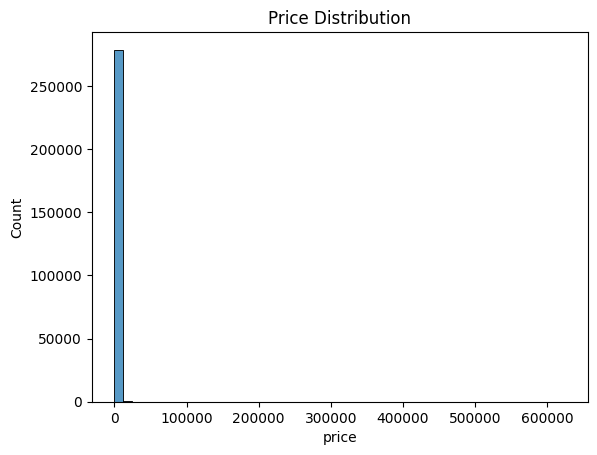

In [14]:
plt.figure()
sns.histplot(listings['price'], bins=50)
plt.title("Price Distribution")
plt.show()

🔹 Cell 5: Top Locations

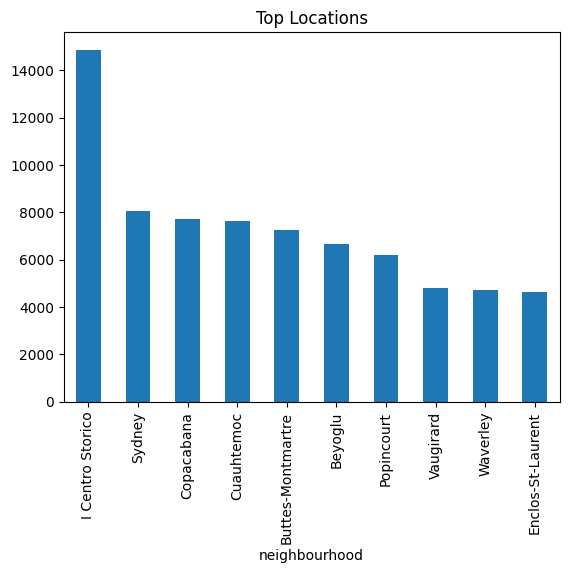

In [16]:
top_locations = listings['neighbourhood'].value_counts().head(10)

plt.figure()
top_locations.plot(kind='bar')
plt.title("Top Locations")
plt.show()

🔹 Cell 6: Reviews Over Time

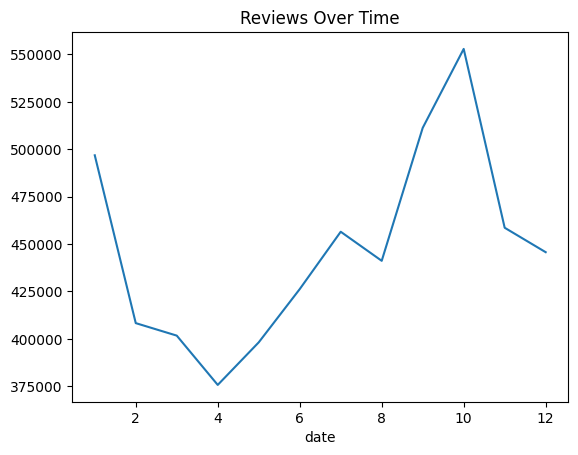

In [17]:
reviews['date'] = pd.to_datetime(reviews['date'])

reviews.groupby(reviews['date'].dt.month).size().plot()
plt.title("Reviews Over Time")
plt.show()

🔹 Cell 6: Handle Missing Values

In [18]:
# Example cleaning (adjust based on your data)
listings = listings.dropna(subset=['listing_id'])

reviews = reviews.dropna(subset=['listing_id'])

🔹 Cell 7: Data Type Fix

In [19]:
# Convert price if exists
if 'price' in listings.columns:
    listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)

# Convert date
if 'date' in reviews.columns:
    reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Shree\AppData\Local\Temp\ipykernel_22160\106301451.py:3: SyntaxWarning: invalid escape sequence '\$'
  listings['price'] = listings['price'].replace('[\$,]', '', regex=True).astype(float)


🔹 Cell 8: Remove Duplicates

In [20]:
listings = listings.drop_duplicates()
reviews = reviews.drop_duplicates()

🔹 Cell 9: Relationship Check

In [21]:
print("Unique listing IDs in listings:", listings['listing_id'].nunique())
print("Unique listing IDs in reviews:", reviews['listing_id'].nunique())

Unique listing IDs in listings: 279712
Unique listing IDs in reviews: 193556


🔹 Cell 10: SAVE CLEAN DATA (MOST IMPORTANT 🔥)

In [22]:
import os

os.makedirs('../data/processed', exist_ok=True)

listings.to_csv('../data/processed/clean_listings.csv', index=False)
reviews.to_csv('../data/processed/clean_reviews.csv', index=False)

print("✅ Clean data saved successfully!")

✅ Clean data saved successfully!


### Key Observations:
- Price is in string format with $
- Missing values present in multiple columns
- Reviews linked using listing_id
- Some duplicate records found